# Experiment - Voxelmorph on deformed masks
- with MSE loss and grad - on one hot encoded masks

In [1]:
%load_ext autoreload
%autoreload 2
from constraints.voxelmorph.models import VxmPairwise
from constraints.generators import ArteryGeneratorDeformed
from constraints import show_torch_image, get_experiment_folder

import pytorch_lightning as pl
import neurite as ne

FOLDER= get_experiment_folder('voxelmorph_test_generator')

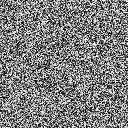

In [2]:
from IPython.display import Image, display
import numpy as np
from PIL import Image as PILImage

arr = (np.random.rand(128,128)*255).astype("uint8")
img = PILImage.fromarray(arr)

display(img)

In [3]:
import torch
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
import numpy as np
import neurite as ne
from torch import nn
import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
dataset_trn = ArteryGeneratorDeformed(num_samples=1000, fixed_seed=42, magnitude=5.0, integrations=0, fractal_mode="upsample")
dataset_val = ArteryGeneratorDeformed(num_samples=100, fixed_seed=43, magnitude=5.0, integrations=0, fractal_mode="upsample")


Using device: cuda


In [4]:
# Sanity check: visualize a few samples from the dataset
sample = dataset_trn[0]
img, mask, template = sample["img"], sample["mask"], sample["template"]
field = sample["field"]
show_torch_image(img, title="Deformed Image", cmap="gray")
show_torch_image(mask, title="Deformed Mask", cmap="gray")
show_torch_image(template, title="Template Image", cmap="gray")
print("Shapes:")
print(f"Image: {img.shape}")
print(f"Mask: {mask.shape}")
print(f"Template: {template.shape}")


Shapes:
Image: torch.Size([1, 256, 256])
Mask: torch.Size([3, 256, 256])
Template: torch.Size([3, 256, 256])


In [5]:
class LitVoxelMorph(pl.LightningModule):
    def __init__(self,grad_loss_weight=0.05):
        super().__init__()
        self.model  = VxmPairwise(
            ndim=2,
            source_channels=3,
            target_channels=3,
            nb_features=[
            [32, 32, 32, 32], # encoder features
            [32, 32, 32, 32]])  # decoder features
        self.image_loss_fn = torch.nn.MSELoss()
        self.grad_loss_fn = ne.nn.modules.SpatialGradient('l2')
        self.grad_loss_weight = grad_loss_weight

    def forward(self, source,target,return_warped_source=True,return_field_type='displacement',return_warped_target=False):
        return self.model(source,target,return_warped_source=return_warped_source,return_field_type=return_field_type,return_warped_target=return_warped_target)

    def _shared_step(self, batch,stage):
        template = batch["template"]
        mask = batch["mask"]
        pred_field, warped_source = self(template, mask, return_warped_source=True, return_field_type='displacement')
        image_loss = self.image_loss_fn(warped_source,mask)
        grad_loss = self.grad_loss_fn(pred_field)
        batch_size = mask.size(0)
        loss = image_loss + self.grad_loss_weight * grad_loss
        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        self.log(f'{stage}_image_loss', image_loss, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f'{stage}_grad_loss', grad_loss, on_step=False, on_epoch=True, batch_size=batch_size)
        return loss
    
    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, 'val')

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        template = batch["template"]
        mask = batch["mask"]
        pred_field, warped_source = self(template, mask, return_warped_source=True, return_field_type='displacement')
        return {
            "mask": mask,
            "template": template,
            "pred_field": pred_field,
            "warped_source": warped_source,
        }

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)


## Deformation only

In [6]:
EPOCHS = 50
from lightning.pytorch.loggers import CSVLogger
from pathlib import Path

ckpt_path = FOLDER / "checkpoints" / "last.ckpt"


logger = CSVLogger('logs', name='experiment')
model = LitVoxelMorph()

# Multiprocessing workers can stall in some Jupyter/cluster setups; start with 0 for reliability.
trn_loader = torch.utils.data.DataLoader(
    dataset_trn,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = torch.utils.data.DataLoader(
    dataset_val,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator='auto',
    devices='auto',
    logger=logger,
    enable_progress_bar=True,
    enable_checkpointing=False,
    log_every_n_steps=1,
    num_sanity_val_steps=0,
    profiler='simple',
)

trainer.fit(
    model,
    train_dataloaders=trn_loader,
    val_dataloaders=val_loader,
    ckpt_path=ckpt_path if ckpt_path.exists() else None,
)


/mnt/appl/software/PyTorch-Lightning/2.5.5-foss-2025a-CUDA-12.8.0/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mrkosmic/.local/lib/python3.13/site-packages/i ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | model         | VxmPairwise     | 112 K  | train
1 | image_loss_fn | MSELoss         | 0      | train
2 | grad_loss_fn  | SpatialGradient | 0      | train
----------------------------------------------------------
112 K     Trainable params
0         Non-trainable params
112 K     Total params
0.451     Total estimated model params size (MB

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
FIT Profiler Report

------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  Action                                                      	|  Mean duration (s)	|  Num calls      	|  Total time (s) 	|  Percentage %   	|
------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  Total                                                       	|  -              	|  51572          	|  199.13         	|  100 %          	|
------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  run_training_epoch                                          	|  3.9737         	|  50             	|  198.68         	|  99.775         	|
|  [_TrainingE

In [9]:
from pathlib import Path
import torch
save_dir = FOLDER / "weights"
save_dir.mkdir(parents=True, exist_ok=True)

weights_path = save_dir / 'lit_voxelmorph_latest.pt'
torch.save(model.state_dict(), weights_path)
print(f'Saved model weights to: {weights_path.resolve()}')

ckpt_path = save_dir / 'lit_voxelmorph_latest.ckpt'
if 'trainer' in globals():
    trainer.save_checkpoint(str(ckpt_path))
    print(f'Saved Lightning checkpoint to: {ckpt_path.resolve()}')
else:
    print('Trainer not found in globals(); skipped .ckpt save.')


Saved model weights to: /mnt/personal/mrkosmic/synced/constraints/outputs/notebooks/voxelmorph_test_generator/weights/lit_voxelmorph_latest.pt
Saved Lightning checkpoint to: /mnt/personal/mrkosmic/synced/constraints/outputs/notebooks/voxelmorph_test_generator/weights/lit_voxelmorph_latest.ckpt


In [10]:

from pathlib import Path
save_dir = FOLDER / "images"
save_dir.mkdir(parents=True, exist_ok=True)
# device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval().to('cpu')
for ex_id in range(10):
    example = dataset_val[ex_id]
    img = example['img'].cpu()
    mask = example['mask'].cpu()
    template = example['template'].cpu()
    with torch.no_grad():
        pred_field, warped_source = model(mask.unsqueeze(0), template.unsqueeze(0), return_warped_source=True, return_field_type='displacement')
    show_torch_image(mask.cpu(), title="Deformed Mask", cmap="gray", save_path=save_dir / f"example_{ex_id}_deformed_mask.png")
    show_torch_image(warped_source.cpu(), title="Warped Mask", cmap="gray", save_path=save_dir / f"example_{ex_id}_warped_mask.png")
    if ex_id == 0:
        show_torch_image(template.cpu(), title="Template Mask", cmap="gray", save_path=save_dir / f"example_{ex_id}_template_mask.png")
